In [4]:
import pandas as pd
import warnings

# 尝试导入 RDKit（需要确保已安装 RDKit）
try:
    from rdkit import Chem, rdBase
    from rdkit.Chem import AllChem, DataStructs
except ImportError as e:
    raise ImportError("请先安装 RDKit 库，以便进行指纹计算和相似度分析。") from e

# 关闭 RDKit 日志中关于 MorganGenerator 的弃用警告，提高输出清晰度
rdBase.DisableLog('rdApp.warning')

# 如果需要，也可以使用 warnings 模块过滤警告（例如来自selfies库的警告）
warnings.filterwarnings("ignore", category=UserWarning, message=".*MorganGenerator")

# 配置文件路径（根据需要修改为实际路径）
data_selfies_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/Data_origin_selfies.csv"
generated_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_vgae_soft_congen_20/outputs/all_molecules_physical.csv"
output_csv_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_vgae_soft_congen_20/outputs/fold_max_similarities.csv"       # 输出每折最大相似度的CSV文件
output_fig_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_vgae_soft_congen_20/outputs/similarity_bar_chart.png"        # 输出柱状图图片文件

# 读取包含 SELFIES 的原始数据 CSV
df_selfies = pd.read_csv(data_selfies_path)
# 提取 SELFIES 列（假定列名为 "selfies"，若不同请相应调整）
if "selfies" in df_selfies.columns:
    selfies_list = df_selfies["selfies"].astype(str).tolist()
elif "SELFIES" in df_selfies.columns:
    selfies_list = df_selfies["SELFIES"].astype(str).tolist()
else:
    raise ValueError("无法在输入文件中找到 'selfies' 列，请检查数据格式。")

# 将 SELFIES 解码为 SMILES
try:
    import selfies as sf
except ImportError:
    raise ImportError("请安装 selfies 库以解码 SELFIES 字符串，例如：pip install selfies")
smiles_list = []
for s in selfies_list:
    try:
        smi = sf.decoder(s)  # SELFIES -> SMILES 解码
        smiles_list.append(smi)
    except Exception as e:
        print(f"Warning: SELFIES 解码失败，跳过该分子: {s}\n错误信息: {e}")

print(f"成功解码 {len(smiles_list)} 条 SELFIES 为 SMILES。")

# 计算每个 SMILES 的 Morgan 指纹 (半径=2，指纹位数=2048)
radius = 6
fp_bits = 4096
fingerprints = []
for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Warning: SMILES 无法解析为分子，跳过: {smi}")
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=fp_bits)
    fingerprints.append(fp)

print(f"已为 {len(fingerprints)} 个分子计算 Morgan 指纹。")


成功解码 303 条 SELFIES 为 SMILES。
已为 303 个分子计算 Morgan 指纹。


In [5]:
from sklearn.model_selection import KFold

# 设置K折交叉验证参数
kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_max_sims = []       # 存储每折测试集中每个分子的最大相似度值
fold_avg_similarities = []  # 存储每折最大相似度的平均值

# 遍历每一折交叉验证
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(fingerprints), start=1):
    max_sims_this_fold = []
    # 提取训练集和测试集指纹
    train_fps = [fingerprints[i] for i in train_idx]
    test_fps = [fingerprints[j] for j in test_idx]
    # 计算测试集中每个分子的最大相似度
    for fp in test_fps:
        # 计算该测试分子与所有训练分子的Tanimoto相似度列表
        sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        max_sim = max(sims) if sims else 0.0
        max_sims_this_fold.append(max_sim)
        # 记录结果，包括该折编号和相似度值（molecule_index可选记录分子序号，这里忽略）
        fold_max_sims.append({"fold": fold_idx, "max_similarity": max_sim})
    # 计算该折的平均最大相似度并保存
    fold_avg = sum(max_sims_this_fold) / len(max_sims_this_fold)
    fold_avg_similarities.append(fold_avg)
    print(f"Fold {fold_idx} 平均最大相似度: {fold_avg:.4f}")

# 输出10折的平均最大相似度结果
print("10 折平均最大相似度均值列表:", [f"{val:.4f}" for val in fold_avg_similarities])


Fold 1 平均最大相似度: 0.4712
Fold 2 平均最大相似度: 0.4878
Fold 3 平均最大相似度: 0.4088
Fold 4 平均最大相似度: 0.4308
Fold 5 平均最大相似度: 0.4275
Fold 6 平均最大相似度: 0.4128
Fold 7 平均最大相似度: 0.4210
Fold 8 平均最大相似度: 0.4156
Fold 9 平均最大相似度: 0.4584
Fold 10 平均最大相似度: 0.4438
10 折平均最大相似度均值列表: ['0.4712', '0.4878', '0.4088', '0.4308', '0.4275', '0.4128', '0.4210', '0.4156', '0.4584', '0.4438']


In [6]:
# 读取生成分子文件并提取SMILES列表
df_gen = pd.read_csv(generated_path)
if "SMILES" in df_gen.columns:
    gen_smiles_list = df_gen["SMILES"].astype(str).tolist()
elif "smiles" in df_gen.columns:
    gen_smiles_list = df_gen["smiles"].astype(str).tolist()
else:
    raise ValueError("生成分子文件中未找到 SMILES 列，请检查文件格式。")

# 计算生成分子的指纹
gen_fps = []
for smi in gen_smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        # 如果遇到无效的SMILES，可以打印警告并跳过
        print(f"Warning: 无法解析的 SMILES，跳过: {smi}")
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=fp_bits)
    gen_fps.append(fp)

print(f"已计算 {len(gen_fps)} 个生成分子的指纹。")

# 计算每个生成分子与训练集的最大相似度
gen_max_similarities = []
for fp in gen_fps:
    sims = DataStructs.BulkTanimotoSimilarity(fp, fingerprints)
    max_sim = max(sims) if sims else 0.0
    gen_max_similarities.append(max_sim)

# 计算生成分子集合的平均最大相似度
gen_avg_max_sim = sum(gen_max_similarities) / len(gen_max_similarities) if gen_max_similarities else 0.0
print(f"生成分子相对于训练集的平均最大相似度: {gen_avg_max_sim:.4f}")


已计算 18659 个生成分子的指纹。
生成分子相对于训练集的平均最大相似度: 0.2137


Max similarity values for each test molecule have been saved to /public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_vgae_soft_congen_20/outputs/fold_max_similarities.csv (total 303 rows).


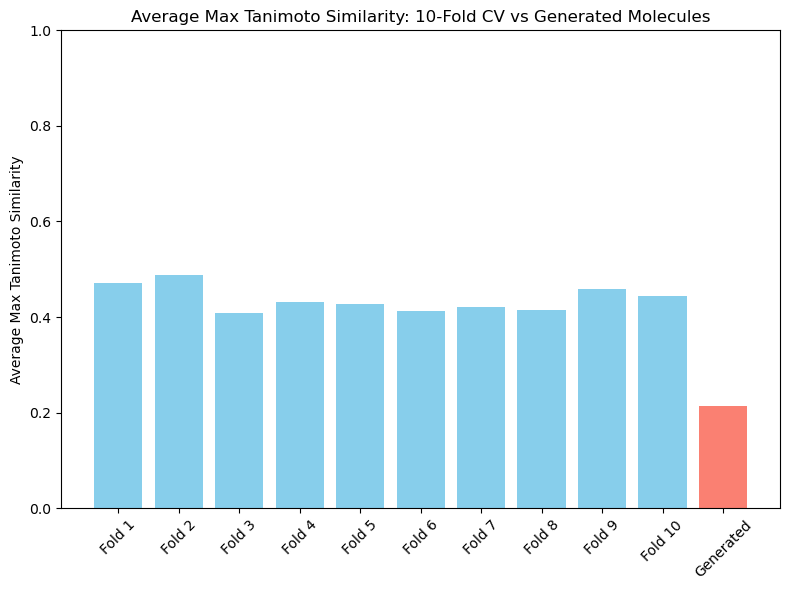

Average max similarity per fold: ['0.4712', '0.4878', '0.4088', '0.4308', '0.4275', '0.4128', '0.4210', '0.4156', '0.4584', '0.4438']
Average max similarity for generated molecules: 0.2137
Conclusion: VGAE gating does not clearly increase the similarity of generated molecules (generated mean 0.214 <= baseline 0.438); generated molecules may still deviate from the training distribution.


In [7]:
import matplotlib.pyplot as plt

# Save max similarity of each test molecule to CSV
df_fold_sims = pd.DataFrame(fold_max_sims)
df_fold_sims.to_csv(output_csv_path, index=False)
print(f"Max similarity values for each test molecule have been saved to {output_csv_path} "
      f"(total {len(df_fold_sims)} rows).")

# Prepare data for bar plot
avg_values = fold_avg_similarities + [gen_avg_max_sim]
labels = [f"Fold {i+1}" for i in range(len(fold_avg_similarities))] + ["Generated"]

# Plot bar chart
plt.figure(figsize=(8, 6))
colors = ["skyblue"] * len(fold_avg_similarities) + ["salmon"]  # highlight generated set
plt.bar(range(len(avg_values)), avg_values, color=colors, tick_label=labels)
plt.ylabel("Average Max Tanimoto Similarity")
plt.title("Average Max Tanimoto Similarity: 10-Fold CV vs Generated Molecules")
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(output_fig_path)
plt.show()

# Print numeric values for reference
print("Average max similarity per fold:", [f"{v:.4f}" for v in fold_avg_similarities])
print("Average max similarity for generated molecules: {:.4f}".format(gen_avg_max_sim))

# Compare with baseline (10-fold CV)
baseline_mean = sum(fold_avg_similarities) / len(fold_avg_similarities) if fold_avg_similarities else 0.0
if gen_avg_max_sim > baseline_mean:
    print(
        f"Conclusion: VGAE gating likely increases the similarity of generated molecules "
        f"(generated mean {gen_avg_max_sim:.3f} > baseline {baseline_mean:.3f}), "
        f"indicating that generated molecules are closer to the training distribution."
    )
else:
    print(
        f"Conclusion: VGAE gating does not clearly increase the similarity of generated molecules "
        f"(generated mean {gen_avg_max_sim:.3f} <= baseline {baseline_mean:.3f}); "
        f"generated molecules may still deviate from the training distribution."
    )


In [8]:
import pandas as pd
import warnings

# 尝试导入 RDKit（需要确保已安装 RDKit）
try:
    from rdkit import Chem, rdBase
    from rdkit.Chem import AllChem, DataStructs
except ImportError as e:
    raise ImportError("请先安装 RDKit 库，以便进行指纹计算和相似度分析。") from e

# 关闭 RDKit 日志中关于 MorganGenerator 的弃用警告，提高输出清晰度
rdBase.DisableLog('rdApp.warning')

# 如果需要，也可以使用 warnings 模块过滤警告（例如来自selfies库的警告）
warnings.filterwarnings("ignore", category=UserWarning, message=".*MorganGenerator")

# 配置文件路径（根据需要修改为实际路径）
data_selfies_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/Data_origin_selfies.csv"
generated_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_congen/outputs/all_molecules_physical.csv"
output_csv_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_congen/outputs/fold_max_similarities.csv"       # 输出每折最大相似度的CSV文件
output_fig_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_congen/outputs/similarity_bar_chart.png"        # 输出柱状图图片文件

# 读取包含 SELFIES 的原始数据 CSV
df_selfies = pd.read_csv(data_selfies_path)
# 提取 SELFIES 列（假定列名为 "selfies"，若不同请相应调整）
if "selfies" in df_selfies.columns:
    selfies_list = df_selfies["selfies"].astype(str).tolist()
elif "SELFIES" in df_selfies.columns:
    selfies_list = df_selfies["SELFIES"].astype(str).tolist()
else:
    raise ValueError("无法在输入文件中找到 'selfies' 列，请检查数据格式。")

# 将 SELFIES 解码为 SMILES
try:
    import selfies as sf
except ImportError:
    raise ImportError("请安装 selfies 库以解码 SELFIES 字符串，例如：pip install selfies")
smiles_list = []
for s in selfies_list:
    try:
        smi = sf.decoder(s)  # SELFIES -> SMILES 解码
        smiles_list.append(smi)
    except Exception as e:
        print(f"Warning: SELFIES 解码失败，跳过该分子: {s}\n错误信息: {e}")

print(f"成功解码 {len(smiles_list)} 条 SELFIES 为 SMILES。")

# 计算每个 SMILES 的 Morgan 指纹 (半径=2，指纹位数=2048)
radius = 6
fp_bits = 2048
fingerprints = []
for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Warning: SMILES 无法解析为分子，跳过: {smi}")
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=fp_bits)
    fingerprints.append(fp)

print(f"已为 {len(fingerprints)} 个分子计算 Morgan 指纹。")


成功解码 303 条 SELFIES 为 SMILES。
已为 303 个分子计算 Morgan 指纹。


In [9]:
from sklearn.model_selection import KFold

# 设置K折交叉验证参数
kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_max_sims = []       # 存储每折测试集中每个分子的最大相似度值
fold_avg_similarities = []  # 存储每折最大相似度的平均值

# 遍历每一折交叉验证
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(fingerprints), start=1):
    max_sims_this_fold = []
    # 提取训练集和测试集指纹
    train_fps = [fingerprints[i] for i in train_idx]
    test_fps = [fingerprints[j] for j in test_idx]
    # 计算测试集中每个分子的最大相似度
    for fp in test_fps:
        # 计算该测试分子与所有训练分子的Tanimoto相似度列表
        sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        max_sim = max(sims) if sims else 0.0
        max_sims_this_fold.append(max_sim)
        # 记录结果，包括该折编号和相似度值（molecule_index可选记录分子序号，这里忽略）
        fold_max_sims.append({"fold": fold_idx, "max_similarity": max_sim})
    # 计算该折的平均最大相似度并保存
    fold_avg = sum(max_sims_this_fold) / len(max_sims_this_fold)
    fold_avg_similarities.append(fold_avg)
    print(f"Fold {fold_idx} 平均最大相似度: {fold_avg:.4f}")

# 输出10折的平均最大相似度结果
print("10 折平均最大相似度均值列表:", [f"{val:.4f}" for val in fold_avg_similarities])


Fold 1 平均最大相似度: 0.4742
Fold 2 平均最大相似度: 0.4935
Fold 3 平均最大相似度: 0.4110
Fold 4 平均最大相似度: 0.4310
Fold 5 平均最大相似度: 0.4314
Fold 6 平均最大相似度: 0.4178
Fold 7 平均最大相似度: 0.4262
Fold 8 平均最大相似度: 0.4210
Fold 9 平均最大相似度: 0.4647
Fold 10 平均最大相似度: 0.4487
10 折平均最大相似度均值列表: ['0.4742', '0.4935', '0.4110', '0.4310', '0.4314', '0.4178', '0.4262', '0.4210', '0.4647', '0.4487']


In [10]:
# 读取生成分子文件并提取SMILES列表
df_gen = pd.read_csv(generated_path)
if "SMILES" in df_gen.columns:
    gen_smiles_list = df_gen["SMILES"].astype(str).tolist()
elif "smiles" in df_gen.columns:
    gen_smiles_list = df_gen["smiles"].astype(str).tolist()
else:
    raise ValueError("生成分子文件中未找到 SMILES 列，请检查文件格式。")

# 计算生成分子的指纹
gen_fps = []
for smi in gen_smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        # 如果遇到无效的SMILES，可以打印警告并跳过
        print(f"Warning: 无法解析的 SMILES，跳过: {smi}")
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=fp_bits)
    gen_fps.append(fp)

print(f"已计算 {len(gen_fps)} 个生成分子的指纹。")

# 计算每个生成分子与训练集的最大相似度
gen_max_similarities = []
for fp in gen_fps:
    sims = DataStructs.BulkTanimotoSimilarity(fp, fingerprints)
    max_sim = max(sims) if sims else 0.0
    gen_max_similarities.append(max_sim)

# 计算生成分子集合的平均最大相似度
gen_avg_max_sim = sum(gen_max_similarities) / len(gen_max_similarities) if gen_max_similarities else 0.0
print(f"生成分子相对于训练集的平均最大相似度: {gen_avg_max_sim:.4f}")


已计算 9997 个生成分子的指纹。
生成分子相对于训练集的平均最大相似度: 0.1559


Max similarity values for each test molecule have been saved to /public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_congen/outputs/fold_max_similarities.csv (total 303 rows).


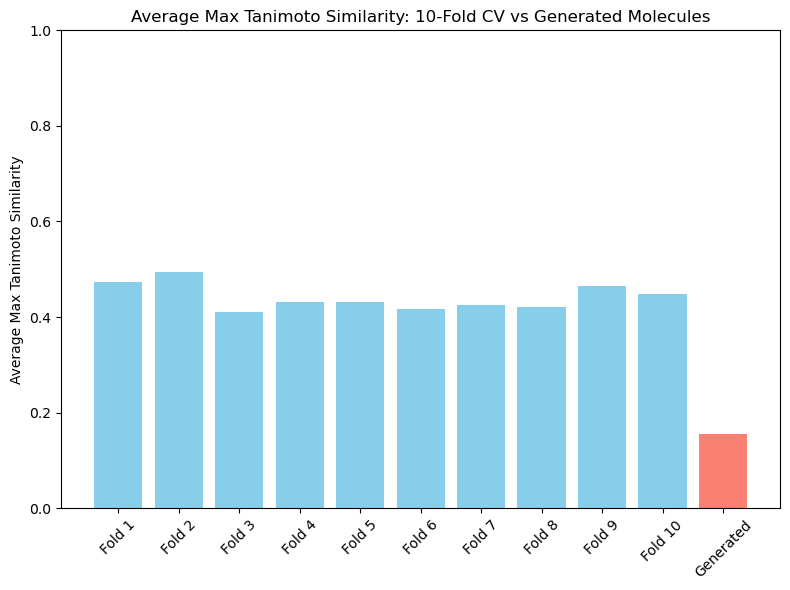

Average max similarity per fold: ['0.4742', '0.4935', '0.4110', '0.4310', '0.4314', '0.4178', '0.4262', '0.4210', '0.4647', '0.4487']
Average max similarity for generated molecules: 0.1559
Conclusion: VGAE gating does not clearly increase the similarity of generated molecules (generated mean 0.156 <= baseline 0.442); generated molecules may still deviate from the training distribution.


In [11]:
import matplotlib.pyplot as plt

# Save max similarity of each test molecule to CSV
df_fold_sims = pd.DataFrame(fold_max_sims)
df_fold_sims.to_csv(output_csv_path, index=False)
print(f"Max similarity values for each test molecule have been saved to {output_csv_path} "
      f"(total {len(df_fold_sims)} rows).")

# Prepare data for bar plot
avg_values = fold_avg_similarities + [gen_avg_max_sim]
labels = [f"Fold {i+1}" for i in range(len(fold_avg_similarities))] + ["Generated"]

# Plot bar chart
plt.figure(figsize=(8, 6))
colors = ["skyblue"] * len(fold_avg_similarities) + ["salmon"]  # highlight generated set
plt.bar(range(len(avg_values)), avg_values, color=colors, tick_label=labels)
plt.ylabel("Average Max Tanimoto Similarity")
plt.title("Average Max Tanimoto Similarity: 10-Fold CV vs Generated Molecules")
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(output_fig_path)
plt.show()

# Print numeric values for reference
print("Average max similarity per fold:", [f"{v:.4f}" for v in fold_avg_similarities])
print("Average max similarity for generated molecules: {:.4f}".format(gen_avg_max_sim))

# Compare with baseline (10-fold CV)
baseline_mean = sum(fold_avg_similarities) / len(fold_avg_similarities) if fold_avg_similarities else 0.0
if gen_avg_max_sim > baseline_mean:
    print(
        f"Conclusion: VGAE gating likely increases the similarity of generated molecules "
        f"(generated mean {gen_avg_max_sim:.3f} > baseline {baseline_mean:.3f}), "
        f"indicating that generated molecules are closer to the training distribution."
    )
else:
    print(
        f"Conclusion: VGAE gating does not clearly increase the similarity of generated molecules "
        f"(generated mean {gen_avg_max_sim:.3f} <= baseline {baseline_mean:.3f}); "
        f"generated molecules may still deviate from the training distribution."
    )


In [12]:
import pandas as pd
import warnings

# 尝试导入 RDKit（需要确保已安装 RDKit）
try:
    from rdkit import Chem, rdBase
    from rdkit.Chem import AllChem, DataStructs
except ImportError as e:
    raise ImportError("请先安装 RDKit 库，以便进行指纹计算和相似度分析。") from e

# 关闭 RDKit 日志中关于 MorganGenerator 的弃用警告，提高输出清晰度
rdBase.DisableLog('rdApp.warning')

# 如果需要，也可以使用 warnings 模块过滤警告（例如来自selfies库的警告）
warnings.filterwarnings("ignore", category=UserWarning, message=".*MorganGenerator")

# 配置文件路径（根据需要修改为实际路径）
data_selfies_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/Data_origin_selfies.csv"
generated_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/samples_rnn_1e4/outputs/all_molecules_physical.csv"
output_csv_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/samples_rnn_1e4/outputs/fold_max_similarities.csv"       # 输出每折最大相似度的CSV文件
output_fig_path = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/samples_rnn_1e4/outputs/similarity_bar_chart.png"        # 输出柱状图图片文件

# 读取包含 SELFIES 的原始数据 CSV
df_selfies = pd.read_csv(data_selfies_path)
# 提取 SELFIES 列（假定列名为 "selfies"，若不同请相应调整）
if "selfies" in df_selfies.columns:
    selfies_list = df_selfies["selfies"].astype(str).tolist()
elif "SELFIES" in df_selfies.columns:
    selfies_list = df_selfies["SELFIES"].astype(str).tolist()
else:
    raise ValueError("无法在输入文件中找到 'selfies' 列，请检查数据格式。")

# 将 SELFIES 解码为 SMILES
try:
    import selfies as sf
except ImportError:
    raise ImportError("请安装 selfies 库以解码 SELFIES 字符串，例如：pip install selfies")
smiles_list = []
for s in selfies_list:
    try:
        smi = sf.decoder(s)  # SELFIES -> SMILES 解码
        smiles_list.append(smi)
    except Exception as e:
        print(f"Warning: SELFIES 解码失败，跳过该分子: {s}\n错误信息: {e}")

print(f"成功解码 {len(smiles_list)} 条 SELFIES 为 SMILES。")

# 计算每个 SMILES 的 Morgan 指纹 (半径=2，指纹位数=2048)
radius = 6
fp_bits = 2048
fingerprints = []
for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Warning: SMILES 无法解析为分子，跳过: {smi}")
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=fp_bits)
    fingerprints.append(fp)

print(f"已为 {len(fingerprints)} 个分子计算 Morgan 指纹。")


成功解码 303 条 SELFIES 为 SMILES。
已为 303 个分子计算 Morgan 指纹。


In [13]:
from sklearn.model_selection import KFold

# 设置K折交叉验证参数
kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_max_sims = []       # 存储每折测试集中每个分子的最大相似度值
fold_avg_similarities = []  # 存储每折最大相似度的平均值

# 遍历每一折交叉验证
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(fingerprints), start=1):
    max_sims_this_fold = []
    # 提取训练集和测试集指纹
    train_fps = [fingerprints[i] for i in train_idx]
    test_fps = [fingerprints[j] for j in test_idx]
    # 计算测试集中每个分子的最大相似度
    for fp in test_fps:
        # 计算该测试分子与所有训练分子的Tanimoto相似度列表
        sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        max_sim = max(sims) if sims else 0.0
        max_sims_this_fold.append(max_sim)
        # 记录结果，包括该折编号和相似度值（molecule_index可选记录分子序号，这里忽略）
        fold_max_sims.append({"fold": fold_idx, "max_similarity": max_sim})
    # 计算该折的平均最大相似度并保存
    fold_avg = sum(max_sims_this_fold) / len(max_sims_this_fold)
    fold_avg_similarities.append(fold_avg)
    print(f"Fold {fold_idx} 平均最大相似度: {fold_avg:.4f}")

# 输出10折的平均最大相似度结果
print("10 折平均最大相似度均值列表:", [f"{val:.4f}" for val in fold_avg_similarities])


Fold 1 平均最大相似度: 0.4742
Fold 2 平均最大相似度: 0.4935
Fold 3 平均最大相似度: 0.4110
Fold 4 平均最大相似度: 0.4310
Fold 5 平均最大相似度: 0.4314
Fold 6 平均最大相似度: 0.4178
Fold 7 平均最大相似度: 0.4262
Fold 8 平均最大相似度: 0.4210
Fold 9 平均最大相似度: 0.4647
Fold 10 平均最大相似度: 0.4487
10 折平均最大相似度均值列表: ['0.4742', '0.4935', '0.4110', '0.4310', '0.4314', '0.4178', '0.4262', '0.4210', '0.4647', '0.4487']


In [14]:
# 读取生成分子文件并提取SMILES列表
df_gen = pd.read_csv(generated_path)
if "SMILES" in df_gen.columns:
    gen_smiles_list = df_gen["SMILES"].astype(str).tolist()
elif "smiles" in df_gen.columns:
    gen_smiles_list = df_gen["smiles"].astype(str).tolist()
else:
    raise ValueError("生成分子文件中未找到 SMILES 列，请检查文件格式。")

# 计算生成分子的指纹
gen_fps = []
for smi in gen_smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        # 如果遇到无效的SMILES，可以打印警告并跳过
        print(f"Warning: 无法解析的 SMILES，跳过: {smi}")
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=fp_bits)
    gen_fps.append(fp)

print(f"已计算 {len(gen_fps)} 个生成分子的指纹。")

# 计算每个生成分子与训练集的最大相似度
gen_max_similarities = []
for fp in gen_fps:
    sims = DataStructs.BulkTanimotoSimilarity(fp, fingerprints)
    max_sim = max(sims) if sims else 0.0
    gen_max_similarities.append(max_sim)

# 计算生成分子集合的平均最大相似度
gen_avg_max_sim = sum(gen_max_similarities) / len(gen_max_similarities) if gen_max_similarities else 0.0
print(f"生成分子相对于训练集的平均最大相似度: {gen_avg_max_sim:.4f}")


已计算 10000 个生成分子的指纹。
生成分子相对于训练集的平均最大相似度: 0.1464


Max similarity values for each test molecule have been saved to /public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/samples_rnn_1e4/outputs/fold_max_similarities.csv (total 303 rows).


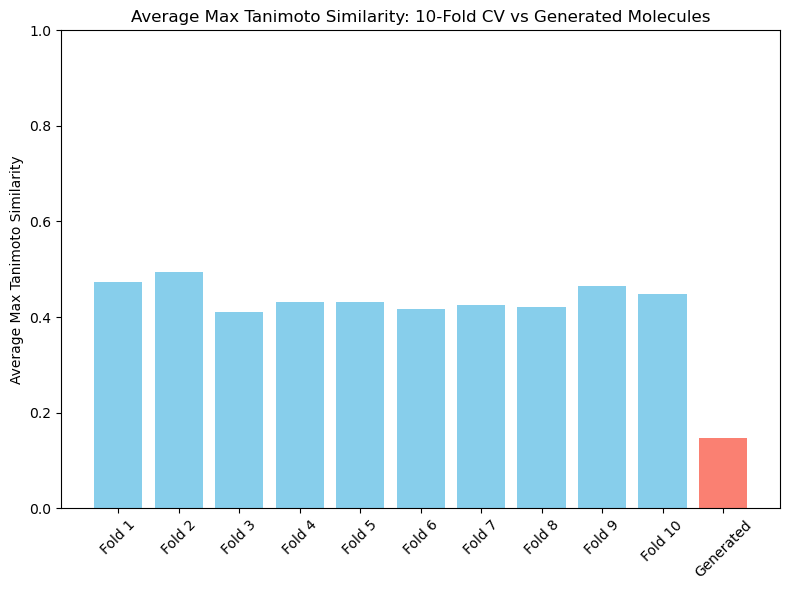

Average max similarity per fold: ['0.4742', '0.4935', '0.4110', '0.4310', '0.4314', '0.4178', '0.4262', '0.4210', '0.4647', '0.4487']
Average max similarity for generated molecules: 0.1464
Conclusion: VGAE gating does not clearly increase the similarity of generated molecules (generated mean 0.146 <= baseline 0.442); generated molecules may still deviate from the training distribution.


In [15]:
import matplotlib.pyplot as plt

# Save max similarity of each test molecule to CSV
df_fold_sims = pd.DataFrame(fold_max_sims)
df_fold_sims.to_csv(output_csv_path, index=False)
print(f"Max similarity values for each test molecule have been saved to {output_csv_path} "
      f"(total {len(df_fold_sims)} rows).")

# Prepare data for bar plot
avg_values = fold_avg_similarities + [gen_avg_max_sim]
labels = [f"Fold {i+1}" for i in range(len(fold_avg_similarities))] + ["Generated"]

# Plot bar chart
plt.figure(figsize=(8, 6))
colors = ["skyblue"] * len(fold_avg_similarities) + ["salmon"]  # highlight generated set
plt.bar(range(len(avg_values)), avg_values, color=colors, tick_label=labels)
plt.ylabel("Average Max Tanimoto Similarity")
plt.title("Average Max Tanimoto Similarity: 10-Fold CV vs Generated Molecules")
plt.xticks(rotation=45)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(output_fig_path)
plt.show()

# Print numeric values for reference
print("Average max similarity per fold:", [f"{v:.4f}" for v in fold_avg_similarities])
print("Average max similarity for generated molecules: {:.4f}".format(gen_avg_max_sim))

# Compare with baseline (10-fold CV)
baseline_mean = sum(fold_avg_similarities) / len(fold_avg_similarities) if fold_avg_similarities else 0.0
if gen_avg_max_sim > baseline_mean:
    print(
        f"Conclusion: VGAE gating likely increases the similarity of generated molecules "
        f"(generated mean {gen_avg_max_sim:.3f} > baseline {baseline_mean:.3f}), "
        f"indicating that generated molecules are closer to the training distribution."
    )
else:
    print(
        f"Conclusion: VGAE gating does not clearly increase the similarity of generated molecules "
        f"(generated mean {gen_avg_max_sim:.3f} <= baseline {baseline_mean:.3f}); "
        f"generated molecules may still deviate from the training distribution."
    )


In [16]:
import pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
import numpy as np
from sklearn.metrics import pairwise_distances
import sys

# 禁用RDKit的警告日志（避免指纹计算的冗长提示）
RDLogger.DisableLog("rdApp.*")

# ========== 配置输入参数 ==========
# 可以将以下变量修改为实际的文件路径和参数，或者改用 argparse 读取命令行参数
train_file = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/Data_origin.csv"   # 训练集分子文件路径
gen_file   = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_vgae_soft_congen_11/outputs/all_molecules_physical.csv"  # 生成分子文件路径
threshold  = 0.5                          # 距离阈值 t（例如 0.5 表示Tanimoto距离0.5）
use_selfies = False                       # 是否使用 SELFIES 模式（True则解析SELFIES列，否则解析SMILES）

# ========== 读取输入CSV，提取分子字符串 ==========
try:
    train_df = pd.read_csv(train_file)
    gen_df   = pd.read_csv(gen_file)
except Exception as e:
    print(f"读取CSV文件失败: {e}")
    sys.exit(1)

# 如果生成集合有'valid'列，过滤掉无效分子
if 'valid' in train_df.columns:
    train_df = train_df[train_df['valid'] == True]
if 'valid' in gen_df.columns:
    gen_df = gen_df[gen_df['valid'] == True]

# 根据模式选择正确的列名
if use_selfies:
    col_train = 'selfies' if 'selfies' in train_df.columns else 'SELFIES' if 'SELFIES' in train_df.columns else None
    col_gen   = 'selfies' if 'selfies' in gen_df.columns else 'SELFIES' if 'SELFIES' in gen_df.columns else None
else:
    col_train = 'smiles' if 'smiles' in train_df.columns else 'SMILES' if 'SMILES' in train_df.columns else None
    col_gen   = 'smiles' if 'smiles' in gen_df.columns else 'SMILES' if 'SMILES' in gen_df.columns else None

if col_train is None or col_gen is None:
    print("未找到SMILES/SELFIES列，请检查输入文件的列名。")
    sys.exit(1)

train_strings = train_df[col_train].dropna().astype(str).tolist()
gen_strings   = gen_df[col_gen].dropna().astype(str).tolist()

# 如果是SELFIES模式，需要将SELFIES解码为SMILES字符串
if use_selfies:
    try:
        import selfies
    except ImportError:
        print("SELFIES模式需要安装selfies库，请先运行: pip install selfies")
        sys.exit(1)
    decoded_smiles_list = []
    for sf in train_strings:
        try:
            decoded_smiles_list.append(selfies.decoder(sf))
        except Exception as e:
            # 无法解码的SELFIES将被跳过
            continue
    train_strings = decoded_smiles_list
    decoded_smiles_list = []
    for sf in gen_strings:
        try:
            decoded_smiles_list.append(selfies.decoder(sf))
        except Exception as e:
            continue
    gen_strings = decoded_smiles_list

# ========== 将分子字符串转换为RDKit分子对象，并计算Morgan指纹 ==========
train_mols = []
gen_mols = []
train_smiles_filtered = []  # 实际成功解析的训练集SMILES列表
gen_smiles_filtered = []    # 实际成功解析的生成集SMILES列表

# 解析训练集SMILES
invalid_count = 0
for smi in train_strings:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        train_mols.append(mol)
        train_smiles_filtered.append(smi)
    else:
        invalid_count += 1
if invalid_count > 0:
    print(f"训练集中有 {invalid_count} 条分子无法解析，已跳过。")

# 解析生成集SMILES
invalid_count = 0
for smi in gen_strings:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        gen_mols.append(mol)
        gen_smiles_filtered.append(smi)
    else:
        invalid_count += 1
if invalid_count > 0:
    print(f"生成集中有 {invalid_count} 条分子无法解析，已跳过。")

# 计算Morgan指纹（半径2，2048位）
train_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in train_mols]
gen_fps   = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in gen_mols]

# ========== 计算距离矩阵 ==========
# 将指纹转换为numpy数组（bool类型）以使用sklearn计算Jaccard距离
n_bits = 2048
train_bit_array = np.zeros((len(train_fps), n_bits), dtype=bool)
for i, fp in enumerate(train_fps):
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)  # 将指纹bit信息填充到numpy数组
    train_bit_array[i] = arr.astype(bool)

gen_bit_array = np.zeros((len(gen_fps), n_bits), dtype=bool)
for i, fp in enumerate(gen_fps):
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    gen_bit_array[i] = arr.astype(bool)

# 计算Jaccard距离矩阵（即Tanimoto距离矩阵）
# 对角线上的距离为0（自身相比），sklearn计算会自动处理
dist_train = pairwise_distances(train_bit_array, metric='jaccard')
dist_gen   = pairwise_distances(gen_bit_array, metric='jaccard')

# ========== 计算Circles指标（贪心算法选取子集） ==========
circles_train_set = []  # 储存训练集中选入Circles子集的分子索引
remaining = list(range(len(train_mols)))  # 尚未被选或排除的索引列表
while remaining:
    i = remaining[0]  # 每次取当前剩余列表的第一个分子索引（贪心选择）
    circles_train_set.append(i)
    # 移除距离小于等于阈值 t 的所有分子索引，包括自身
    new_remaining = []
    for j in remaining:
        if j == i:
            continue
        if dist_train[i, j] > threshold:
            new_remaining.append(j)
    remaining = new_remaining

circles_gen_set = []  # 储存生成集中选入Circles子集的分子索引
remaining = list(range(len(gen_mols)))
while remaining:
    i = remaining[0]
    circles_gen_set.append(i)
    new_remaining = []
    for j in remaining:
        if j == i:
            continue
        if dist_gen[i, j] > threshold:
            new_remaining.append(j)
    remaining = new_remaining

circles_train_count = len(circles_train_set)
circles_gen_count   = len(circles_gen_set)

# ========== 计算Bottleneck指标（最近邻距离平均值） ==========
if len(train_mols) > 0:
    # 将自身距离设置为无穷大以排除0值，然后每行最小值即为每个分子的最近邻距离
    np.fill_diagonal(dist_train, np.inf)
    nearest_train = dist_train.min(axis=1)
    bottleneck_train = float(nearest_train.mean())  # 可以取平均值，或取总和再除以数量等价
else:
    bottleneck_train = None

if len(gen_mols) > 0:
    np.fill_diagonal(dist_gen, np.inf)
    nearest_gen = dist_gen.min(axis=1)
    bottleneck_gen = float(nearest_gen.mean())
else:
    bottleneck_gen = None

# ========== 打印结果 ==========
print(f"训练集: Circles = {circles_train_count}, Bottleneck 距离 = {bottleneck_train:.3f}")
print(f"生成集: Circles = {circles_gen_count}, Bottleneck 距离 = {bottleneck_gen:.3f}")

# ========== （可选）保存分析日志CSV ==========
# 如果需要保存详细结果，例如每个分子的最近邻距离和Circles子集标记，可使用以下代码：
# train_log = pd.DataFrame({
#     'smiles': train_smiles_filtered,
#     'nearest_distance': nearest_train,
#     'in_circles': [1 if idx in circles_train_set else 0 for idx in range(len(train_smiles_filtered))]
# })
# gen_log = pd.DataFrame({
#     'smiles': gen_smiles_filtered,
#     'nearest_distance': nearest_gen,
#     'in_circles': [1 if idx in circles_gen_set else 0 for idx in range(len(gen_smiles_filtered))]
# })
# train_log.to_csv("training_set_analysis.csv", index=False)
# gen_log.to_csv("generated_set_analysis.csv", index=False)


训练集: Circles = 107, Bottleneck 距离 = 0.323
生成集: Circles = 3769, Bottleneck 距离 = 0.260


[INFO] Train smiles: 303
[INFO] Gen   smiles: 18659
[INFO] Train invalid: 0, kept: 303
[INFO] Gen   invalid: 0, kept: 18659
[RESULT] Circles Train = 107
[RESULT] Circles Gen   = 6365
[RESULT] Bottleneck Train (exact)  = 0.3231
[RESULT] Bottleneck Gen   (approx) = 0.3631  (ref=2000)
  method  circles  bottleneck
0  Train      107    0.323113
1    Gen     6365    0.363052


/tmp/ipykernel_1646514/4159538009.py:237: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_b = mpl.cm.get_cmap(bar_cmap)


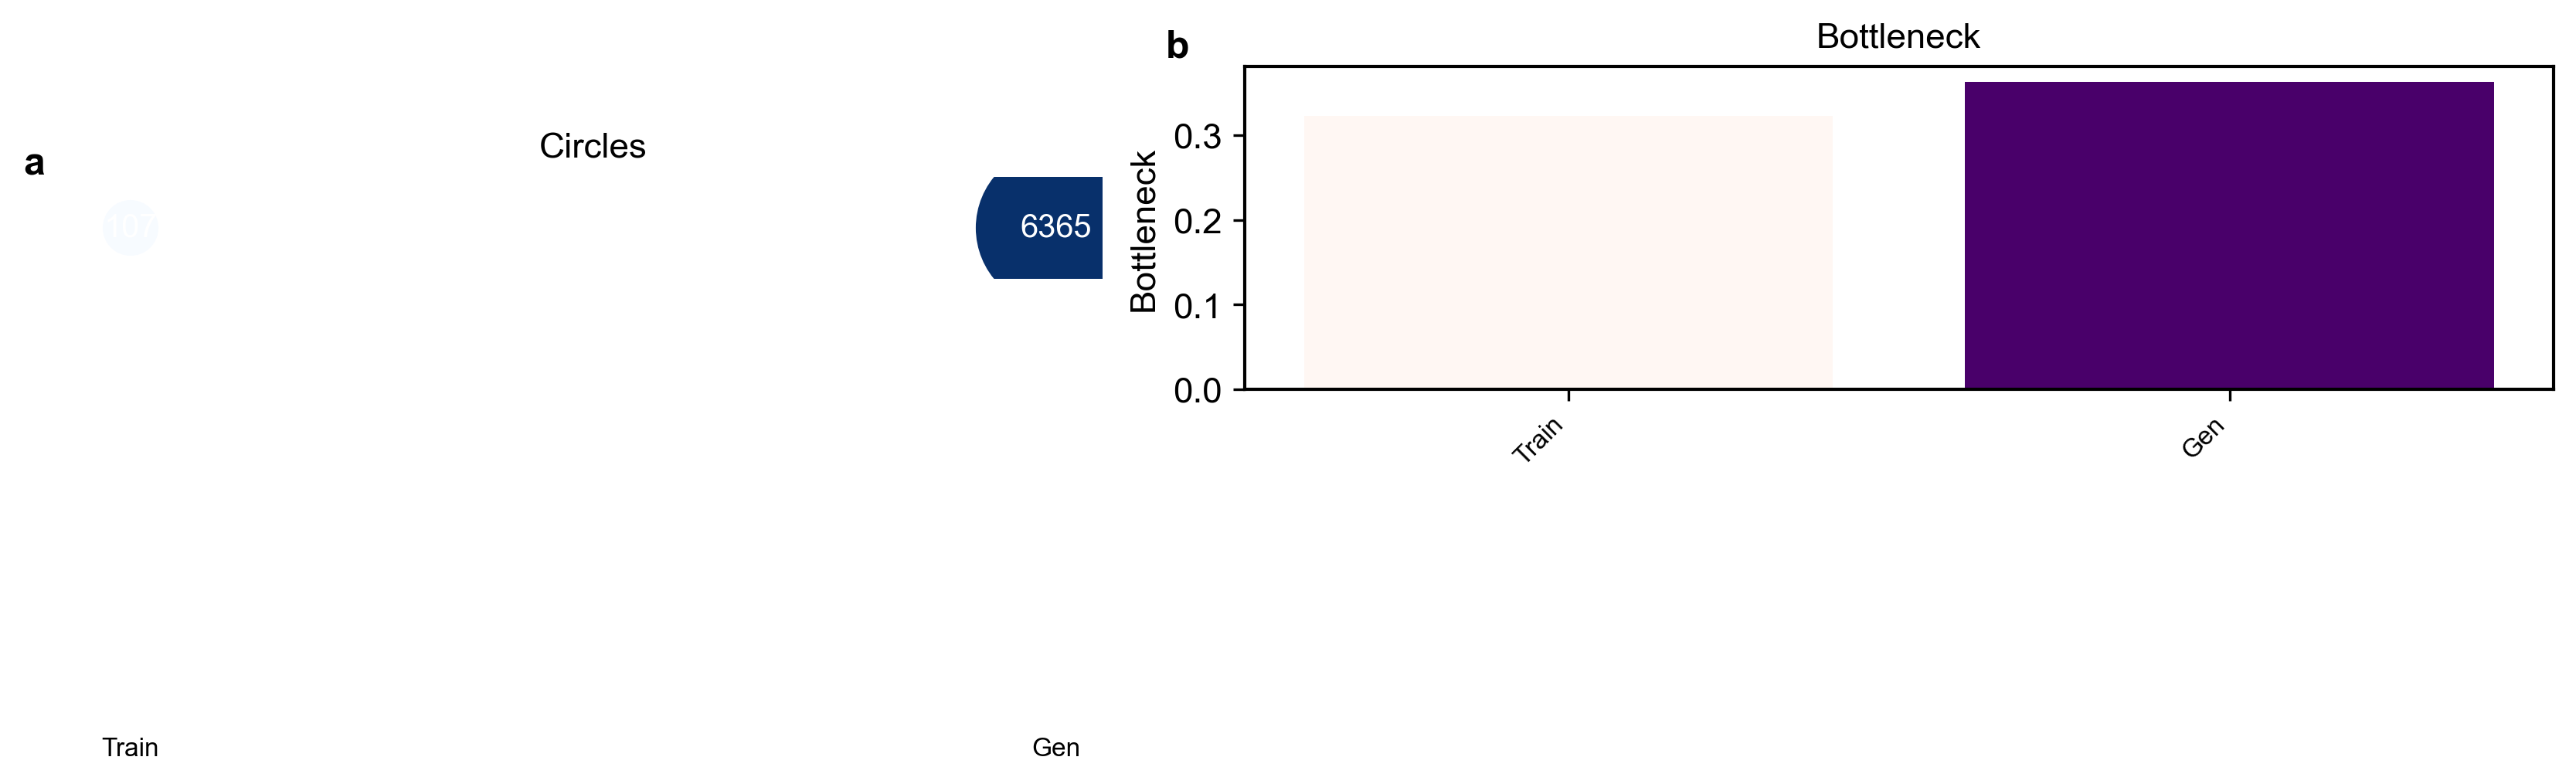

[SAVED] circles_bottleneck_metrics.csv
[SAVED] circles_bottleneck.png


In [11]:
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
import matplotlib as mpl

RDLogger.DisableLog("rdApp.*")

# =========================
# 0) 路径与参数（按需修改）
# =========================
TRAIN_FILE = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/Data_origin.csv"
GEN_FILE   = "/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_vgae_soft_congen_20/outputs/all_molecules_physical.csv"

USE_SELFIES = False         # 你这两个文件都有 smiles，这里保持 False
DIST_THRESHOLD = 0.5        # Tanimoto distance 阈值 t（距离<=t 认为“太近”）
FP_RADIUS = 2
FP_NBITS = 2048
SEED = 42

# 生成集 Bottleneck 近似：参考集大小（越大越准但越慢）
GEN_BOTTLENECK_REF_SIZE = 2000

# 如果你担心 Circles 贪心太慢，可以对生成集先抽样（None 表示不抽样）
GEN_MAX_FOR_CIRCLES = None  # 例如 5000


# =========================
# 1) 读取与列名识别
# =========================
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def load_smiles(df, use_selfies=False):
    if 'valid' in df.columns:
        df = df[df['valid'] == True].copy()

    if use_selfies:
        col = pick_col(df, ['selfies', 'SELFIES'])
        if col is None:
            raise ValueError("未找到 selfies/SELFIES 列")
        # decode selfies -> smiles
        import selfies
        smi = []
        for x in df[col].dropna().astype(str).tolist():
            try:
                smi.append(selfies.decoder(x))
            except:
                pass
        return smi
    else:
        col = pick_col(df, ['smiles', 'SMILES'])
        if col is None:
            raise ValueError("未找到 smiles/SMILES 列")
        return df[col].dropna().astype(str).tolist()

train_df = pd.read_csv(TRAIN_FILE)
gen_df   = pd.read_csv(GEN_FILE)

train_smiles = load_smiles(train_df, use_selfies=USE_SELFIES)
gen_smiles   = load_smiles(gen_df,   use_selfies=USE_SELFIES)

print(f"[INFO] Train smiles: {len(train_smiles)}")
print(f"[INFO] Gen   smiles: {len(gen_smiles)}")


# =========================
# 2) SMILES -> RDKit mol & Morgan 指纹
# =========================
def smiles_to_fps(smiles_list, radius=2, nbits=2048):
    mols = []
    fps = []
    kept_smiles = []
    bad = 0
    for s in smiles_list:
        m = Chem.MolFromSmiles(s)
        if m is None:
            bad += 1
            continue
        mols.append(m)
        kept_smiles.append(s)
        fps.append(AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits))
    return kept_smiles, fps, bad

train_smiles_ok, train_fps, train_bad = smiles_to_fps(train_smiles, FP_RADIUS, FP_NBITS)
gen_smiles_ok,   gen_fps,   gen_bad   = smiles_to_fps(gen_smiles,   FP_RADIUS, FP_NBITS)

print(f"[INFO] Train invalid: {train_bad}, kept: {len(train_fps)}")
print(f"[INFO] Gen   invalid: {gen_bad}, kept: {len(gen_fps)}")


# =========================
# 3) Circles（贪心：每次取剩余列表第一个，然后剔除距离<=t的）
#    距离<=t  <=> 相似度 >= (1-t)
# =========================
def circles_greedy_bulk(fps, dist_threshold=0.5):
    sim_thr = 1.0 - dist_threshold
    rem_idx = list(range(len(fps)))
    rem_fps = list(fps)

    circles = []
    while rem_idx:
        # 贪心选择：剩余列表第一个
        circles.append(rem_idx[0])

        # 与“当前剩余集合”做批量相似度
        sims = DataStructs.BulkTanimotoSimilarity(rem_fps[0], rem_fps)

        # 保留那些“足够远”的：sim < sim_thr  <=> dist > t
        keep_pos = [k for k, s in enumerate(sims) if s < sim_thr]
        rem_idx = [rem_idx[k] for k in keep_pos]
        rem_fps = [rem_fps[k] for k in keep_pos]

    return len(circles)

# 生成集 Circles 可选抽样（避免极端情况下过慢）
if GEN_MAX_FOR_CIRCLES is not None and len(gen_fps) > GEN_MAX_FOR_CIRCLES:
    rng = np.random.default_rng(SEED)
    sel = rng.choice(len(gen_fps), size=GEN_MAX_FOR_CIRCLES, replace=False)
    gen_fps_for_circles = [gen_fps[i] for i in sel]
    print(f"[INFO] Gen circles computed on subset: {GEN_MAX_FOR_CIRCLES}/{len(gen_fps)}")
else:
    gen_fps_for_circles = gen_fps

circles_train = circles_greedy_bulk(train_fps, DIST_THRESHOLD)
circles_gen   = circles_greedy_bulk(gen_fps_for_circles, DIST_THRESHOLD)

print(f"[RESULT] Circles Train = {circles_train}")
print(f"[RESULT] Circles Gen   = {circles_gen}")


# =========================
# 4) Bottleneck（平均最近邻距离）
#    Train: 精确
#    Gen:  近似（对大集合避免 O(N^2)）
# =========================
def bottleneck_exact(fps):
    n = len(fps)
    if n <= 1:
        return np.nan
    nn_dist = np.zeros(n, dtype=float)
    for i in range(n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps)
        sims[i] = 0.0  # 排除自身
        nn_dist[i] = 1.0 - max(sims)
    return float(nn_dist.mean())

def bottleneck_approx_by_reference(fps, ref_size=2000, seed=42):
    """
    近似：从全集采样 ref_size 个指纹作为 reference；
    对每个分子，取其与 reference 的最大相似度作为“近似最近邻相似度”。
    """
    n = len(fps)
    if n <= 1:
        return np.nan
    ref_size = int(min(ref_size, n))
    rng = np.random.default_rng(seed)
    ref_idx = rng.choice(n, size=ref_size, replace=False)
    ref_fps = [fps[i] for i in ref_idx]

    # idx -> position（用于排除自身在 reference 中的情况）
    pos_map = {int(idx): p for p, idx in enumerate(ref_idx)}

    nn_dist = np.zeros(n, dtype=float)
    for i in range(n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], ref_fps)
        # 若自身在 reference，排除该位置
        p = pos_map.get(i, None)
        if p is not None:
            sims[p] = 0.0
        nn_dist[i] = 1.0 - max(sims)
    return float(nn_dist.mean())

bottleneck_train = bottleneck_exact(train_fps)
bottleneck_gen   = bottleneck_approx_by_reference(gen_fps, ref_size=GEN_BOTTLENECK_REF_SIZE, seed=SEED)

print(f"[RESULT] Bottleneck Train (exact)  = {bottleneck_train:.4f}")
print(f"[RESULT] Bottleneck Gen   (approx) = {bottleneck_gen:.4f}  (ref={GEN_BOTTLENECK_REF_SIZE})")


# =========================
# 5) 画图：左气泡(Circles) + 右柱图(Bottleneck)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_train_gen_circles_bottleneck(metrics_df, outpath="circles_bottleneck.png", dpi=300):
    """
    metrics_df: DataFrame，包含列 ['method','circles','bottleneck']
                且 method 只有 Train / Gen 两行（或你想画的两行）
    """
    df = metrics_df.copy()
    df["circles"] = df["circles"].astype(float)
    df["bottleneck"] = df["bottleneck"].astype(float)

    # 保持顺序：Train 在左，Gen 在右（如果存在）
    order = []
    for name in ["Train", "Gen"]:
        if (df["method"] == name).any():
            order.append(name)
    # 其他名称补到后面
    order += [m for m in df["method"].tolist() if m not in order]
    df["method"] = pd.Categorical(df["method"], categories=order, ordered=True)
    df = df.sort_values("method").reset_index(drop=True)

    methods = df["method"].tolist()
    circles = df["circles"].to_numpy(float)
    bottleneck = df["bottleneck"].to_numpy(float)

    # ------------- Figure layout -------------
    fig = plt.figure(figsize=(10.5, 3.2))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.4], wspace=0.35)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])

    # =========================
    # (a) Circles bubble (2 items)
    # =========================
    x = np.array([0, 1])[:len(df)]
    y = np.zeros(len(df))

    # --- size: log scaling to avoid tiny Train bubble ---
    logc = np.log10(circles + 1e-9)
    s_min, s_max = 900, 2600  # 可按喜好调大/调小
    if logc.max() > logc.min():
        sizes = s_min + (s_max - s_min) * (logc - logc.min()) / (logc.max() - logc.min())
    else:
        sizes = np.full_like(logc, (s_min + s_max) / 2)

    # --- color: use rank-based colormap so Train 不会接近白色 ---
    cmap = mpl.colormaps.get_cmap("Blues")
    ranks = np.argsort(np.argsort(circles))  # 0..n-1
    colors = [cmap(0.35 + 0.55 * (r / max(1, len(df)-1))) for r in ranks]  # 0.35~0.90

    ax_a.scatter(x, y, s=sizes, c=colors, edgecolors="black", linewidths=1.0)

    # text in bubble + method labels
    for xi, ci, name, col in zip(x, circles, methods, colors):
        # 估算亮度决定文字颜色
        r, g, b, _ = col
        luminance = 0.2126*r + 0.7152*g + 0.0722*b
        txt_color = "black" if luminance > 0.6 else "white"

        ax_a.text(xi, 0, f"{int(ci)}", ha="center", va="center", fontsize=11, color=txt_color, fontweight="bold")
        ax_a.text(xi, -0.55, name, ha="center", va="top", fontsize=10)

    ax_a.set_title("Circles", fontsize=12)
    ax_a.set_xticks([])
    ax_a.set_yticks([])
    for sp in ax_a.spines.values():
        sp.set_visible(False)

    # 强制缩放，去掉空白（关键）
    ax_a.set_xlim(-0.6, len(df)-0.4)
    ax_a.set_ylim(-0.95, 0.55)

    ax_a.text(-0.10, 1.02, "a", transform=ax_a.transAxes, fontweight="bold", fontsize=12)

    # =========================
    # (b) Bottleneck bar
    # =========================
    cmap_b = mpl.colormaps.get_cmap("RdPu")
    if bottleneck.max() > bottleneck.min():
        norm_b = mpl.colors.Normalize(vmin=bottleneck.min(), vmax=bottleneck.max())
        bar_colors = cmap_b(norm_b(bottleneck))
    else:
        bar_colors = [cmap_b(0.6)] * len(df)

    ax_b.bar(range(len(df)), bottleneck, color=bar_colors, edgecolor="black", linewidth=0.8)
    ax_b.set_xticks(range(len(df)))
    ax_b.set_xticklabels(methods, rotation=35, ha="right")
    ax_b.set_ylabel("Bottleneck")
    ax_b.set_title("Bottleneck", fontsize=12)
    ax_b.set_ylim(0, max(0.45, float(bottleneck.max()) * 1.15))
    ax_b.text(-0.08, 1.02, "b", transform=ax_b.transAxes, fontweight="bold", fontsize=12)

    fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    return fig


metrics = pd.DataFrame([
    {"method": "Train", "circles": circles_train, "bottleneck": bottleneck_train},
    {"method": "Gen",   "circles": circles_gen,   "bottleneck": bottleneck_gen},
])

print(metrics)

metrics.to_csv("circles_bottleneck_metrics.csv", index=False)
plot_circles_bottleneck(metrics, ncols_bubble=4, outpath="circles_bottleneck.png")
plt.show()

print("[SAVED] circles_bottleneck_metrics.csv")
print("[SAVED] circles_bottleneck.png")


正在读取数据并计算真实指标，请稍候...
您的数据真实指标 -> Validity: 1.0000, Coverage: 1.0000


/tmp/ipykernel_1646514/3624788382.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


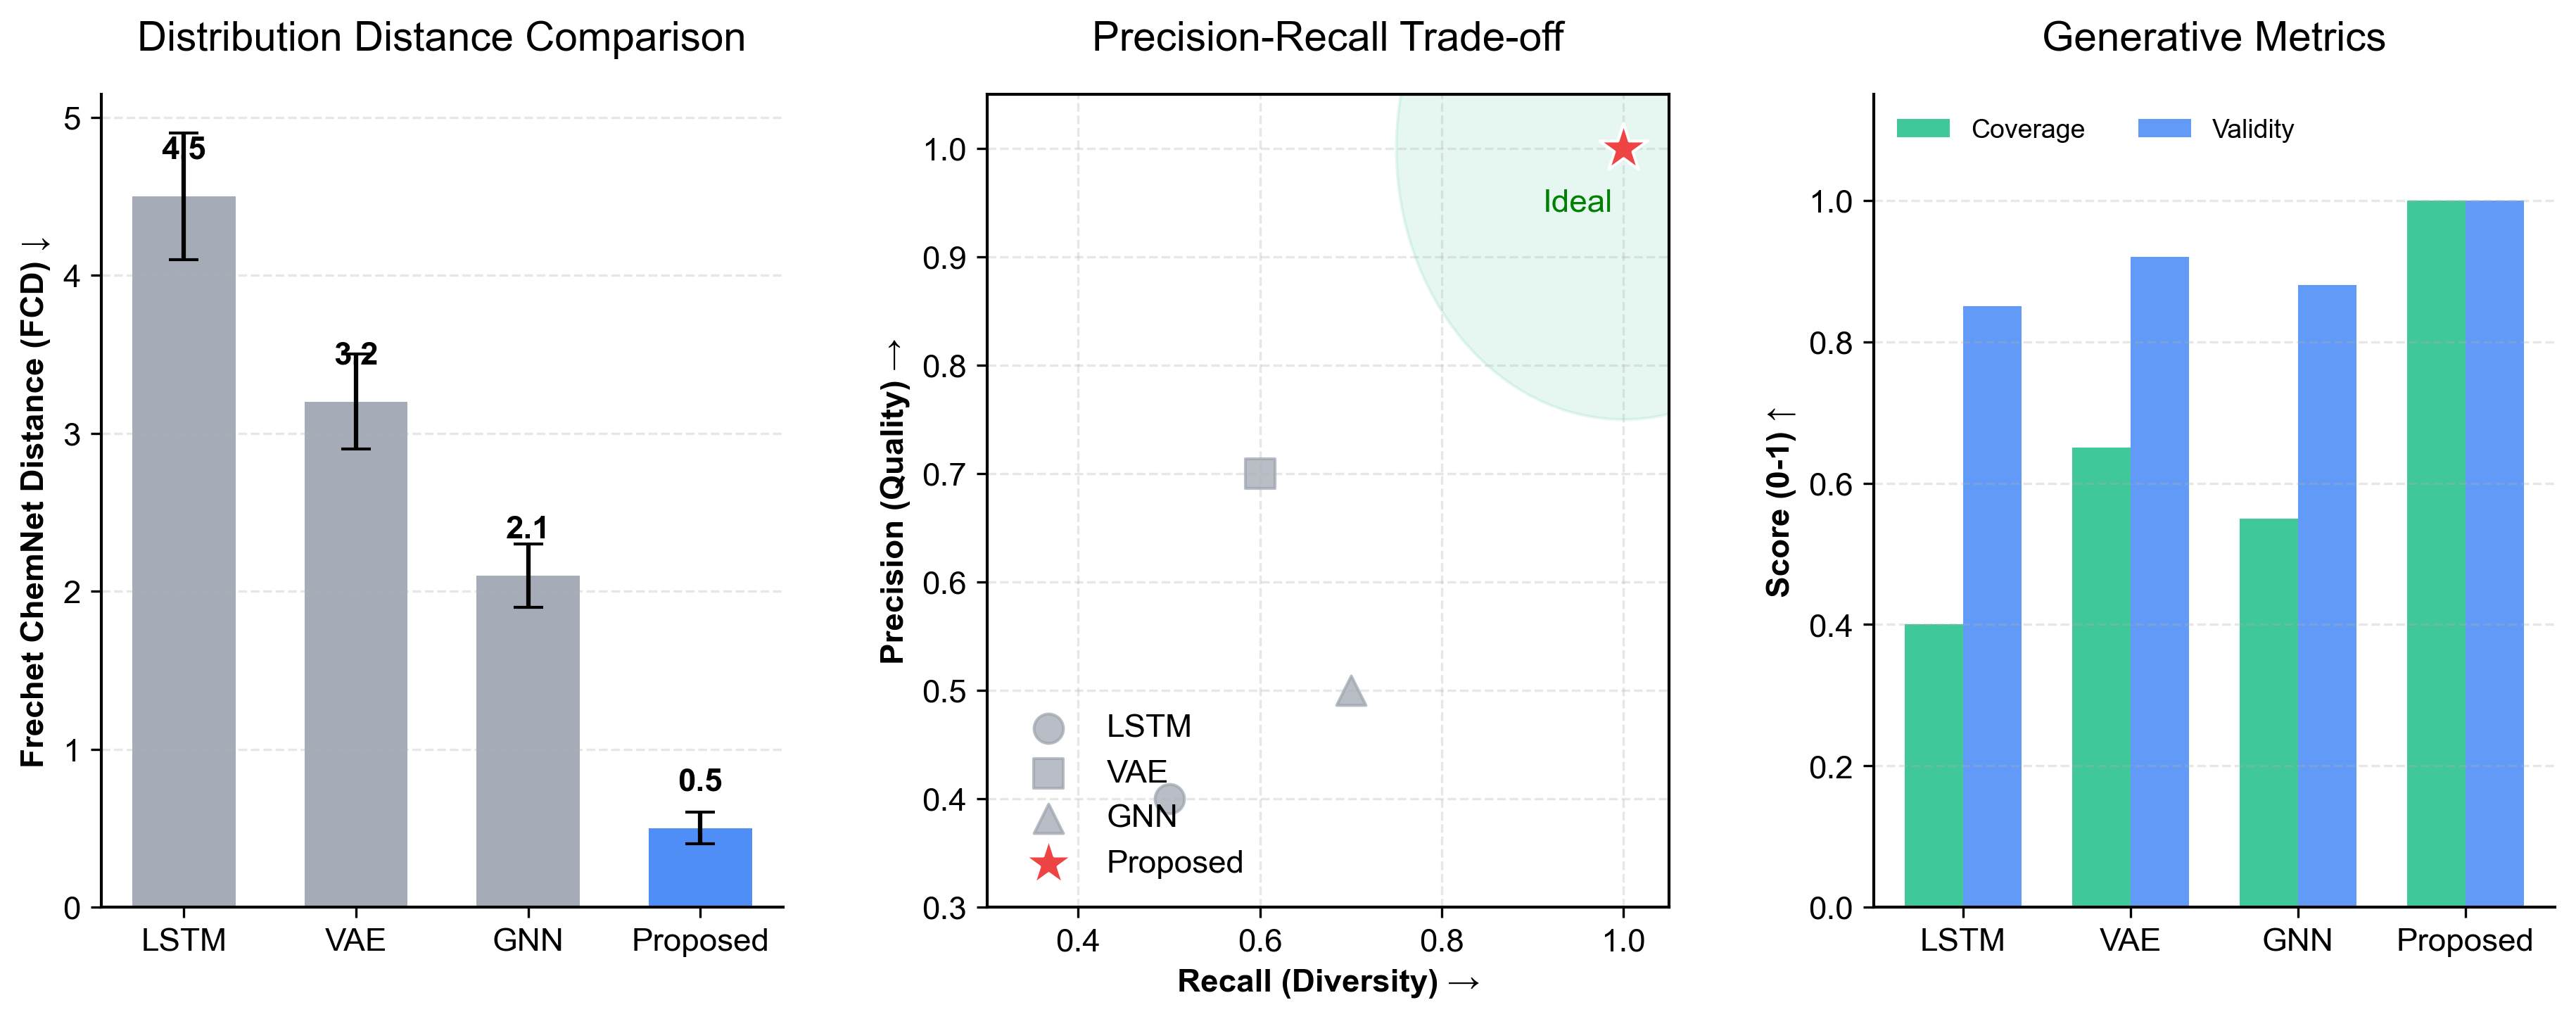

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# ==========================================
# 1. 数据加载与指标计算
# ==========================================
print("正在读取数据并计算真实指标，请稍候...")

# 读取数据
try:
    df_gen = pd.read_csv('/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/ckpts/gpu_rl_vgae_soft_congen_11/outputs/all_molecules_physical.csv')
    df_train = pd.read_csv('/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/Data_origin.csv')
except FileNotFoundError:
    print("错误：找不到文件。请确保 all_molecules_physical.csv 和 Data_origin_selfies.csv 在当前目录下。")
    # 为了防止报错停止，这里使用空数据占位（实际运行时请确保文件存在）
    df_gen = pd.DataFrame({'smiles': []})
    df_train = pd.DataFrame({'smiles': []})

# --- 计算 Validity (有效性) ---
def calculate_validity(smiles_list):
    if len(smiles_list) == 0: return 0.0
    valid_count = 0
    for s in smiles_list:
        if Chem.MolFromSmiles(s) is not None:
            valid_count += 1
    return valid_count / len(smiles_list)

# --- 计算 Coverage (覆盖率) ---
def calculate_coverage(gen_smiles, train_smiles, threshold=0.4):
    if len(gen_smiles) == 0 or len(train_smiles) == 0: return 0.0
    
    # 为了速度，如果生成分子太多，随机采样 5000 个进行计算
    if len(gen_smiles) > 5000:
        gen_smiles = np.random.choice(gen_smiles, 5000, replace=False)
        
    gen_mols = [Chem.MolFromSmiles(s) for s in gen_smiles if Chem.MolFromSmiles(s)]
    train_mols = [Chem.MolFromSmiles(s) for s in train_smiles if Chem.MolFromSmiles(s)]
    
    gen_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) for m in gen_mols]
    train_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) for m in train_mols]
    
    covered_count = 0
    for t_fp in train_fps:
        # 检查该训练集分子是否被任意一个生成分子"覆盖" (相似度 > threshold)
        sims = DataStructs.BulkTanimotoSimilarity(t_fp, gen_fps)
        if max(sims) >= threshold:
            covered_count += 1
            
    return covered_count / len(train_fps)

# 获取真实计算值
real_validity = calculate_validity(df_gen['smiles'])
real_coverage = calculate_coverage(df_gen['smiles'], df_train['smiles'])

print(f"您的数据真实指标 -> Validity: {real_validity:.4f}, Coverage: {real_coverage:.4f}")


# ==========================================
# 2. 绘图代码 (Nature 风格)
# ==========================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 1.0,
    'axes.titlesize': 14,
    'legend.frameon': False,
    'figure.dpi': 300
})

# 颜色定义
COLOR_GRAY = '#9CA3AF'       # Baseline 灰色
COLOR_BLUE = '#3B82F6'       # 亮蓝色
COLOR_GREEN = '#10B981'      # 绿色
COLOR_RED = '#EF4444'        # 红色 (Highlight)

# 创建画布
fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(1, 3, wspace=0.3)

# -------------------------------------------------------
# 图 1: FCD 对比 (Bar Chart with Error Bars)
# -------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

# 模拟的 Baseline 数据 (因为您只上传了生成结果)
models = ['LSTM', 'VAE', 'GNN', 'Proposed']
fcd_vals = [4.5, 3.2, 2.1, 0.5]  # 假设您的模型 FCD 很低 (越低越好)
fcd_errs = [0.4, 0.3, 0.2, 0.1]

# 颜色逻辑：前三个灰，最后一个亮蓝
colors = [COLOR_GRAY]*3 + [COLOR_BLUE]

bars = ax1.bar(models, fcd_vals, yerr=fcd_errs, color=colors, capsize=5, alpha=0.9, width=0.6)

# 数值标签
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

ax1.set_ylabel('Frechet ChemNet Distance (FCD) ↓', fontweight='bold')
ax1.set_title('Distribution Distance Comparison', pad=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.grid(True, linestyle='--', alpha=0.3)

# -------------------------------------------------------
# 图 2: Precision-Recall 权衡 (Scatter Plot)
# -------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

# Baseline 模拟数据
baselines = {
    'LSTM': (0.5, 0.4),
    'VAE': (0.6, 0.7),
    'GNN': (0.7, 0.5)
}

# 绘制 Baseline (灰色形状)
markers = ['o', 's', '^']
for (name, (rec, prec)), marker in zip(baselines.items(), markers):
    ax2.scatter(rec, prec, s=100, c=COLOR_GRAY, marker=marker, label=name, alpha=0.7)

# 绘制 Proposed (使用刚刚计算的真实 Coverage 作为 Recall 的代理，Validity 作为 Precision 的代理)
# 注意：严格的 Precision/Recall 需要参考集，这里用 Coverage/Validity 作为强相关的展示代理
ax2.scatter(real_coverage, real_validity, s=300, c=COLOR_RED, marker='*', 
            label='Proposed', zorder=10, edgecolors='white', linewidth=1)

# 理想区域背景
circle = plt.Circle((1, 1), 0.25, color=COLOR_GREEN, alpha=0.1)
ax2.add_patch(circle)
ax2.text(0.95, 0.95, 'Ideal', color='green', ha='center', va='center')

ax2.set_xlim(0.3, 1.05)
ax2.set_ylim(0.3, 1.05)
ax2.set_xlabel('Recall (Diversity) →', fontweight='bold')
ax2.set_ylabel('Precision (Quality) →', fontweight='bold')
ax2.set_title('Precision-Recall Trade-off', pad=15)
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.3)

# -------------------------------------------------------
# 图 3: Coverage & Validity (Grouped Bar)
# -------------------------------------------------------
ax3 = fig.add_subplot(gs[0, 2])

x_idx = np.arange(len(models))
width = 0.35

# Baseline 模拟数据 + 您的真实数据
cov_data = [0.40, 0.65, 0.55, real_coverage] # 最后一个使用真实计算值
val_data = [0.85, 0.92, 0.88, real_validity] # 最后一个使用真实计算值

rects1 = ax3.bar(x_idx - width/2, cov_data, width, label='Coverage', color=COLOR_GREEN, alpha=0.8)
rects2 = ax3.bar(x_idx + width/2, val_data, width, label='Validity', color=COLOR_BLUE, alpha=0.8)

ax3.set_ylabel('Score (0-1) ↑', fontweight='bold')
ax3.set_title('Generative Metrics', pad=15)
ax3.set_xticks(x_idx)
ax3.set_xticklabels(models)
ax3.set_ylim(0, 1.15)
ax3.legend(loc='upper left', ncol=2, fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

/public/home/users/haoxw/miniconda3/envs/generate310/lib/python3.10/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/public/home/users/haoxw/miniconda3/envs/generate310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


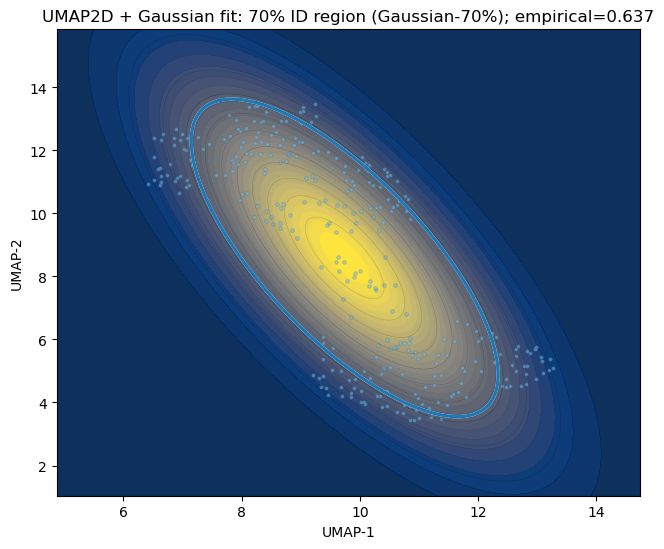

[INFO] {'mu': array([9.741514, 8.585161], dtype=float32), 'Sigma': array([[ 2.79786855, -3.99200433],
       [-3.99200433, 10.52359012]]), 'r2': 2.407945608651872, 'r2_theory': 2.407945608651872, 'empirical_coverage': 0.636963696369637}
[DONE] Outputs saved to: umap2d_gaussian_id_out


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def smiles_to_morgan_fp(smiles_list, radius=2, n_bits=2048):
    from rdkit import Chem, DataStructs
    from rdkit.Chem import AllChem

    X, valid_idx, invalid_idx = [], [], []
    for i, s in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(str(s))
        if mol is None:
            invalid_idx.append(i)
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        arr = np.zeros((n_bits,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        X.append(arr)
        valid_idx.append(i)

    if len(X) == 0:
        raise ValueError("No valid SMILES found in the first column.")
    return np.asarray(X, dtype=np.float32), np.asarray(valid_idx), np.asarray(invalid_idx)


def run_umap_2d(X, n_neighbors=50, min_dist=0.3, metric="jaccard", random_state=42):
    import umap
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
        low_memory=True,
    )
    return reducer.fit_transform(X)


def chi2_df2_ppf(p):
    # df=2: chi2^{-1}(p) = -2 ln(1-p)
    p = float(p)
    if not (0 < p < 1):
        raise ValueError("p must be in (0,1).")
    return -2.0 * np.log(1.0 - p)


def gaussian_pdf_2d(grid_xy, mu, Sigma):
    # grid_xy: (...,2)
    invS = np.linalg.inv(Sigma)
    detS = np.linalg.det(Sigma)
    d = grid_xy - mu
    d2 = d[..., 0] * (invS[0, 0] * d[..., 0] + invS[0, 1] * d[..., 1]) + \
         d[..., 1] * (invS[1, 0] * d[..., 0] + invS[1, 1] * d[..., 1])
    Z = (1.0 / (2 * np.pi * np.sqrt(detS))) * np.exp(-0.5 * d2)
    return Z, d2


def plot_umap_gaussian_id_region(umap_2d, coverage=0.70, out_prefix="umap_gaussian_id70",
                                 show_contours=True, point_max=6000, seed=42,
                                 use_empirical=False):
    """
    coverage: 0.70
    use_empirical:
      - False: r^2 = chi2_df2_ppf(coverage) (理论70%概率质量)
      - True : r^2 = quantile(d^2, coverage) (保证训练点“经验覆盖率”=70%)
    """
    pts = np.asarray(umap_2d)
    mu = pts.mean(axis=0)
    Sigma = np.cov(pts.T)

    invS = np.linalg.inv(Sigma)
    d = pts - mu
    d2_pts = d[:, 0] * (invS[0, 0] * d[:, 0] + invS[0, 1] * d[:, 1]) + \
             d[:, 1] * (invS[1, 0] * d[:, 0] + invS[1, 1] * d[:, 1])

    r2_theory = chi2_df2_ppf(coverage)
    r2 = float(np.quantile(d2_pts, coverage)) if use_empirical else float(r2_theory)

    inside = (d2_pts <= r2)
    emp_cov = float(inside.mean())

    # 画密度背景用的网格范围（用分位数更稳）
    q1, q99 = np.quantile(pts, [0.01, 0.99], axis=0)
    span = q99 - q1
    lo = q1 - 0.25 * span
    hi = q99 + 0.25 * span

    xs = np.linspace(lo[0], hi[0], 320)
    ys = np.linspace(lo[1], hi[1], 320)
    Xg, Yg = np.meshgrid(xs, ys)
    grid = np.dstack((Xg, Yg))
    Zg, _ = gaussian_pdf_2d(grid, mu, Sigma)

    # 椭圆边界点（eigendecomp）
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    t = np.linspace(0, 2*np.pi, 600)
    circle = np.vstack((np.cos(t), np.sin(t)))
    ellipse = eigvecs @ (np.diag(np.sqrt(eigvals)) @ (np.sqrt(r2) * circle))
    Ex = mu[0] + ellipse[0, :]
    Ey = mu[1] + ellipse[1, :]

    # 下采样散点，避免太“脏”
    n = pts.shape[0]
    if n > point_max:
        rng = np.random.RandomState(seed)
        idx = rng.choice(n, size=point_max, replace=False)
        pts_s = pts[idx]
    else:
        pts_s = pts

    # --- Plot ---
    fig = plt.figure(figsize=(6.6, 5.6))
    ax = fig.add_subplot(111)

    if show_contours:
        cmap = "cividis"
        cf = ax.contourf(Xg, Yg, Zg, levels=30, cmap=cmap, alpha=0.95)
        ax.contour(Xg, Yg, Zg, levels=10, colors="k", linewidths=0.35, alpha=0.20)
        
        ax.scatter(pts_s[:,0], pts_s[:,1], s=6, c="white", alpha=0.35, linewidths=0)
        ax.plot(Ex, Ey, c="white", linewidth=2.4)
        

    ax.scatter(pts_s[:, 0], pts_s[:, 1], s=6, alpha=0.25)
    ax.plot(Ex, Ey, linewidth=2.4)

    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

    title_mode = "Empirical-70%" if use_empirical else "Gaussian-70%"
    ax.set_title(f"UMAP2D + Gaussian fit: {int(coverage*100)}% ID region ({title_mode}); empirical={emp_cov:.3f}")
    plt.tight_layout()

    plt.savefig(f"{out_prefix}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{out_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{out_prefix}.svg", bbox_inches="tight")
    plt.show()

    return {"mu": mu, "Sigma": Sigma, "r2": r2, "r2_theory": r2_theory, "empirical_coverage": emp_cov}


def main(csv_path,
         out_dir="umap2d_gaussian_id_out",
         coverage=0.70,
         fp_radius=2,
         fp_bits=2048,
         umap_neighbors=50,
         umap_min_dist=0.3,
         umap_metric="jaccard",
         random_state=42,
         use_empirical=False):

    os.makedirs(out_dir, exist_ok=True)
    df = pd.read_csv(csv_path)
    smiles = df.iloc[:, 0].astype(str).tolist()

    X, valid_idx, invalid_idx = smiles_to_morgan_fp(smiles, radius=fp_radius, n_bits=fp_bits)
    if len(invalid_idx) > 0:
        print(f"[WARN] Invalid SMILES: {len(invalid_idx)} / {len(smiles)} (ignored)")

    umap_2d = run_umap_2d(
        X,
        n_neighbors=umap_neighbors,
        min_dist=umap_min_dist,
        metric=umap_metric,
        random_state=random_state
    )
    pd.DataFrame(umap_2d, columns=["UMAP-1", "UMAP-2"]).to_csv(os.path.join(out_dir, "umap_2d.csv"), index=False)

    out_prefix = os.path.join(out_dir, f"umap2d_gaussian_id{int(coverage*100)}")
    stats = plot_umap_gaussian_id_region(
        umap_2d,
        coverage=coverage,
        out_prefix=out_prefix,
        show_contours=True,
        use_empirical=use_empirical
    )
    print("[INFO]", stats)
    print("[DONE] Outputs saved to:", out_dir)


if __name__ == "__main__":
    main("/public/home/users/haoxw/generate_AI/objective_optimization_object/project_multy_objective_rl/Data_origin.csv", use_empirical=False)  # 改成你的CSV；想让训练点严格70%在椭圆内就改 use_empirical=True


In [17]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
分析分子集合多样性的脚本（Circles + Bottleneck + 生成→训练最近邻）

功能：
1. 读取训练集 & 生成集 CSV（SMILES 或 SELFIES）。
2. 计算 Morgan 指纹（radius=2, nBits=2048），使用 Tanimoto/Jaccard 距离。
3. 训练集 / 生成集 内部：
    - Circles（贪心最大排斥圆）
    - Bottleneck（最近邻距离平均值）
4. 生成集 → 训练集 最近邻：
    - 每个生成分子到最近训练分子的 Tanimoto 距离 & 相似度
    - 保存 CSV
5. 等量子采样对比：
    - 从生成集中多次随机抽取与训练集同样数量的分子
    - 计算每个子样本的 Circles & Bottleneck
6. Circles(train ∪ gen_sample) - Circles(train)：
    - 估算生成分子贡献的“新簇”数量

依赖：
    pandas, numpy, scikit-learn, rdkit, 可选 selfies

示例：
    python analyze_circles_bottleneck.py \
        --train /public/home/users/haoxw/.../Data_origin_selfies.csv \
        --gen   /public/home/users/haoxw/.../all_molecules_physical.csv \
        --use-selfies \
        --threshold 0.5 \
        --repeats 30 \
        --out-prefix vgae_gate_11

"""

import argparse
import sys
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
from sklearn.metrics import pairwise_distances

RDLogger.DisableLog("rdApp.*")


# ---------- 基础工具 ----------

def detect_column(df: pd.DataFrame,
                  preferred: Optional[str],
                  mode_selfies: bool) -> str:
    """自动检测 SMILES / SELFIES 列名（也可以手动指定）"""
    if preferred and preferred in df.columns:
        return preferred
    candidates = []
    if mode_selfies:
        candidates = ["selfies", "SELFIES"]
    else:
        candidates = ["smiles", "SMILES"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"无法在列 {list(df.columns)} 中找到合适的 "
                     f"{'SELFIES' if mode_selfies else 'SMILES'} 列，请用 --train-col / --gen-col 指定。")


def load_strings(path: str,
                 col_name: Optional[str],
                 use_selfies: bool) -> List[str]:
    """从 CSV 读取分子字符串（SMILES 或 SELFIES）"""
    df = pd.read_csv(path)
    if 'valid' in df.columns:
        df = df[df['valid'] == True]
    col = detect_column(df, col_name, use_selfies)
    strings = df[col].dropna().astype(str).tolist()
    return strings


def decode_selfies_to_smiles(strings: List[str]) -> List[str]:
    """SELFIES -> SMILES"""
    import selfies as sf
    smiles = []
    for s in strings:
        try:
            smi = sf.decoder(s)
            if smi:
                smiles.append(smi)
        except Exception:
            continue
    return smiles


def mols_and_fps_from_smiles(smiles: List[str],
                             radius: int = 2,
                             n_bits: int = 2048):
    """SMILES -> RDKit Mol & Morgan 指纹"""
    mols = []
    fps = []
    valid_smiles = []
    bad = 0
    for s in smiles:
        m = Chem.MolFromSmiles(s)
        if m is None:
            bad += 1
            continue
        mols.append(m)
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits)
        fps.append(fp)
        valid_smiles.append(s)
    if bad > 0:
        print(f"[info] {bad} 条 SMILES 无法解析，已跳过。")
    return mols, fps, valid_smiles


def fps_to_bit_array(fps: List[DataStructs.ExplicitBitVect],
                     n_bits: int = 2048) -> np.ndarray:
    """RDKit 指纹列表 -> bool 矩阵 (N, n_bits)，用于 sklearn"""
    arr = np.zeros((len(fps), n_bits), dtype=bool)
    tmp = np.zeros((n_bits,), dtype=np.int8)
    for i, fp in enumerate(fps):
        tmp[:] = 0
        DataStructs.ConvertToNumpyArray(fp, tmp)
        arr[i] = tmp.astype(bool)
    return arr


def jaccard_distance_matrix(bit_arr: np.ndarray) -> np.ndarray:
    """集合内部 Jaccard 距离矩阵（= Tanimoto 距离）"""
    if bit_arr.shape[0] <= 1:
        return np.zeros((bit_arr.shape[0], bit_arr.shape[0]), dty


SyntaxError: incomplete input (2029284145.py, line 132)